In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("/content/sample_data/orders_return.csv")
df

,order_id,customer_id,order_date,region,category,quantity,unit_price,discount,payment_type,campaign_flag,order_value,returned
0,1,103,2022-11-01,North,Skincare,4,227.69,0,Card,1,910.76,1
1,2,271,2023-03-05,North,Haircare,1,317.61,10,Card,0,285.85,0
2,3,107,2023-04-22,North,Clothing,3,246.09,0,Wallet,0,738.27,0
3,4,72,2022-10-13,East,Haircare,1,137.58,5,Card,0,130.70,0
4,5,189,2022-05-24,East,Skincare,4,245.81,0,Card,0,983.24,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,215,2023-07-15,West,Electronics,1,106.55,0,Card,1,106.55,1
996,997,211,2023-04-28,South,Skincare,1,219.37,0,Card,0,219.37,0
997,998,32,2022-04-18,West,Haircare,1,240.10,0,Wallet,1,240.10,0
998,999,158,2022-08-14,South,Oralcare,3,218.19,15,UPI,0,556.38,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       1000 non-null   int64  
 1   customer_id    1000 non-null   int64  
 2   order_date     1000 non-null   object 
 3   region         1000 non-null   object 
 4   category       1000 non-null   object 
 5   quantity       1000 non-null   int64  
 6   unit_price     1000 non-null   float64
 7   discount       1000 non-null   int64  
 8   payment_type   1000 non-null   object 
 9   campaign_flag  1000 non-null   int64  
 10  order_value    1000 non-null   float64
 11  returned       1000 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 93.9+ KB


In [18]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.drop('order_id', axis=1)

In [21]:
df

,customer_id,order_date,region,category,quantity,unit_price,discount,payment_type,campaign_flag,order_value,returned
0,103,2022-11-01,North,Skincare,4,227.69,0,Card,1,910.76,1
1,271,2023-03-05,North,Haircare,1,317.61,10,Card,0,285.85,0
2,107,2023-04-22,North,Clothing,3,246.09,0,Wallet,0,738.27,0
3,72,2022-10-13,East,Haircare,1,137.58,5,Card,0,130.70,0
4,189,2022-05-24,East,Skincare,4,245.81,0,Card,0,983.24,1
...,...,...,...,...,...,...,...,...,...,...,...
995,215,2023-07-15,West,Electronics,1,106.55,0,Card,1,106.55,1
996,211,2023-04-28,South,Skincare,1,219.37,0,Card,0,219.37,0
997,32,2022-04-18,West,Haircare,1,240.10,0,Wallet,1,240.10,0
998,158,2022-08-14,South,Oralcare,3,218.19,15,UPI,0,556.38,0


In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
le  = LabelEncoder()

In [33]:
for i in df.columns:
 if df[i].dtype =='object':
  df[i]=le.fit_transform(df[i])

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    1000 non-null   int64  
 1   order_date     1000 non-null   int64  
 2   region         1000 non-null   int64  
 3   category       1000 non-null   int64  
 4   quantity       1000 non-null   int64  
 5   unit_price     1000 non-null   float64
 6   discount       1000 non-null   int64  
 7   payment_type   1000 non-null   int64  
 8   campaign_flag  1000 non-null   int64  
 9   order_value    1000 non-null   float64
 10  returned       1000 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 86.1 KB


In [44]:
from sklearn.model_selection  import *
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


In [39]:
X  = df.drop(['returned'], axis=1)
y = df['returned']

In [40]:
X

,customer_id,order_date,region,category,quantity,unit_price,discount,payment_type,campaign_flag,order_value
0,103,225,1,5,4,227.69,0,1,1,910.76
1,271,321,1,2,1,317.61,10,1,0,285.85
2,107,350,1,0,3,246.09,0,3,0,738.27
3,72,209,0,2,1,137.58,5,1,0,130.70
4,189,104,0,5,4,245.81,0,1,0,983.24
...,...,...,...,...,...,...,...,...,...,...
995,215,406,3,1,1,106.55,0,1,1,106.55
996,211,353,2,5,1,219.37,0,1,0,219.37
997,32,78,3,2,1,240.10,0,3,1,240.10
998,158,166,2,4,3,218.19,15,2,0,556.38


In [42]:
y

,returned
0,1
1,0
2,0
3,0
4,1
...,...
995,1
996,0
997,0
998,0


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.20, random_state=42)

In [51]:
std = StandardScaler()

In [52]:
X_train_scaled = std.fit_transform(X_train)
X_test_scled = std.fit_transform(X_test)

In [53]:
lg = LogisticRegression()

In [62]:
model_logistic = lg.fit(X_train_scaled, y_train)
model_logistic

LogisticRegression()

In [73]:
y_pred_logistic = model_logistic.predict(X_test_scled)

In [74]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93       200
           1       0.00      0.00      0.00         0

    accuracy                           0.88       200
   macro avg       0.50      0.44      0.47       200
weighted avg       1.00      0.88      0.93       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [75]:
acc = accuracy_score(y_pred , y_test)*100
acc

87.5

In [76]:
from sklearn.tree import DecisionTreeClassifier

In [94]:
dc = DecisionTreeClassifier(max_depth=10, min_samples_split=4, criterion='gini')

In [95]:
model_Decision = dc.fit(X_train_scaled , y_train)
model_Decision

DecisionTreeClassifier(max_depth=10, min_samples_split=4)

In [96]:
y_pred_Decision = model_Decision.predict(X_test_scled)

In [97]:
print(classification_report(y_pred_Decision , y_test))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89       182
           1       0.04      0.06      0.05        18

    accuracy                           0.80       200
   macro avg       0.47      0.46      0.47       200
weighted avg       0.83      0.80      0.81       200



In [98]:
from sklearn.ensemble import RandomForestClassifier

In [100]:
random = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=10, min_samples_split=2, verbose=1)

In [102]:
model_random = random.fit(X_train_scaled , y_train)
model_random

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


RandomForestClassifier(max_depth=10, verbose=1)

In [103]:
y_pred_random = model_random.predict(X_test_scled)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [104]:
print(classification_report(y_pred_random , y_test))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93       200
           1       0.00      0.00      0.00         0

    accuracy                           0.88       200
   macro avg       0.50      0.44      0.47       200
weighted avg       1.00      0.88      0.93       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [111]:
from  xgboost import XGBClassifier

In [112]:
model_xg= XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    objective='binary:logistic')

In [113]:
model_xg.fit(X_train_scaled , y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [114]:
y_pred_xg = model_xg.predict(X_test_scled)

In [115]:
print(classification_report(y_pred_xg , y_test))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92       193
           1       0.04      0.14      0.06         7

    accuracy                           0.85       200
   macro avg       0.50      0.51      0.49       200
weighted avg       0.93      0.85      0.89       200



In [117]:
from sklearn.neighbors import KNeighborsClassifier

In [118]:
KNN = KNeighborsClassifier(n_neighbors=5)

In [120]:
model_knn = KNN.fit(X_train_scaled , y_train)
model_knn

KNeighborsClassifier()

In [121]:
y_pred_knn = model_knn.predict(X_test_scled)

In [122]:
print(classification_report(y_pred_knn , y_test))

              precision    recall  f1-score   support

           0       0.98      0.87      0.92       197
           1       0.00      0.00      0.00         3

    accuracy                           0.86       200
   macro avg       0.49      0.44      0.46       200
weighted avg       0.97      0.86      0.91       200



In [124]:
from sklearn.svm import SVC

In [125]:
svm = SVC(kernel='rbf', degree=3, gamma='scale')

In [126]:
model_svm = svm.fit(X_train_scaled , y_train)
model_svm

SVC()

In [127]:
y_pred_svm = model_svm.predict(X_test_scled)

In [128]:
print(classification_report(y_pred_svm , y_test))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93       200
           1       0.00      0.00      0.00         0

    accuracy                           0.88       200
   macro avg       0.50      0.44      0.47       200
weighted avg       1.00      0.88      0.93       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipykernel_1268/1046936407.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


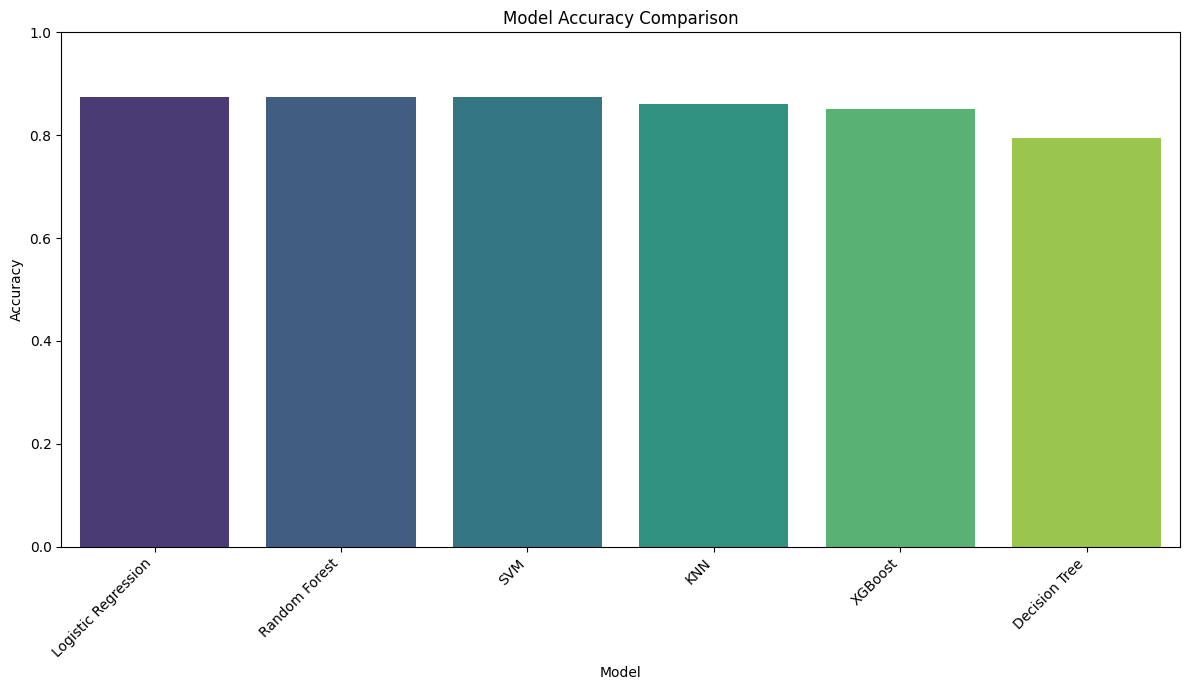

In [129]:
model_accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_pred_logistic),
    'Decision Tree': accuracy_score(y_test, y_pred_Decision),
    'Random Forest': accuracy_score(y_test, y_pred_random),
    'XGBoost': accuracy_score(y_test, y_pred_xg),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'SVM': accuracy_score(y_test, y_pred_svm)
}

accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()